# 1. Setup and Initialization

In [1]:
# Importing Necessary Libraries

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors as mcolors
from scipy.stats import linregress
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
from tabulate import tabulate
from collections import Counter

%matplotlib inline

In [2]:
# Initialize Plotly for use in the notebook
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

# Configure Seaborn plot styles: Set background color and use dark grid
sns.set(rc={'axes.facecolor': '#fcf0dc'}, style='darkgrid')

In [3]:
# Loading the Dataset

df = pd.read_csv('kindle_data-v2.csv')

Dataset Description

asin
Product ID from Amazon. (type: str)

title
Title of the book. (type: str)

author
Author(s) of the book. (type: str)

soldBy
Seller(s) of the book. (type: str)

imgUrl
URL of the book cover image. (type: str)

productURL
URL of the book. (type: str)

stars
Average rating of the book. If 0, no ratings were found. (type: float)

reviews
Number of reviews. If 0, no reviews were found. (type: int)

price
Price of the book. If 0, price was unavailable. (type: float)

isKindleUnlimited
Whether the book is available through Kindle Unlimited. (type: bool)

category_id
Serial id assigned to the category this book belong to. (type: int)

isBestSeller
Whether the book had the Amazon Best Seller status or not. (type: bool)

isEditorsPick
Whether the book had the Editor's Pick status or not. (type: bool)

isGoodReadsChoice
Whether the book had the Goodreads Choice status or not. (type: bool)

publishedDate
Publication date of the book. (type: str, format: YYY-YMM-DD)

category_name
Name of the book category. (type: str)

In [4]:
# Initial Data Analysis
df.head(10)

,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,category_id,isBestSeller,isEditorsPick,isGoodReadsChoice,publishedDate,category_name
0,B00TZE87S4,Adult Children of Emotionally Immature Parents...,Lindsay C. Gibson,Amazon.com Services LLC,https://m.media-amazon.com/images/I/713KZTsaYp...,https://www.amazon.com/dp/B00TZE87S4,4.8,0,9.99,False,6,True,False,False,2015-06-01,Parenting & Relationships
1,B08WCKY8MB,"From Strength to Strength: Finding Success, Ha...",Arthur C. Brooks,Penguin Group (USA) LLC,https://m.media-amazon.com/images/I/A1LZcJFs9E...,https://www.amazon.com/dp/B08WCKY8MB,4.4,0,16.99,False,6,False,False,False,2022-02-15,Parenting & Relationships
2,B09KPS84CJ,Good Inside: A Guide to Becoming the Parent Yo...,Becky Kennedy,HarperCollins Publishers,https://m.media-amazon.com/images/I/71RIWM0sv6...,https://www.amazon.com/dp/B09KPS84CJ,4.8,0,16.99,False,6,False,True,False,2022-09-13,Parenting & Relationships
3,B07S7QPG6J,Everything I Know About Love: A Memoir,Dolly Alderton,HarperCollins Publishers,https://m.media-amazon.com/images/I/71QdQpTiKZ...,https://www.amazon.com/dp/B07S7QPG6J,4.2,0,9.95,True,6,False,True,False,2020-02-25,Parenting & Relationships
4,B00N6PEQV0,The Seven Principles for Making Marriage Work:...,John Gottman,Random House LLC,https://m.media-amazon.com/images/I/813o4WOs+w...,https://www.amazon.com/dp/B00N6PEQV0,4.7,0,13.99,False,6,False,False,False,2015-05-05,Parenting & Relationships
5,B000OVLKMM,The Glass Castle: A Memoir,Jeannette Walls,Simon and Schuster Digital Sales Inc,https://m.media-amazon.com/images/I/71td5GDUZM...,https://www.amazon.com/dp/B000OVLKMM,4.6,0,13.99,False,6,False,False,False,2005-03-01,Parenting & Relationships
6,B00AEBEQUK,Expecting Better: Why the Conventional Pregnan...,Emily Oster,Penguin Group (USA) LLC,https://m.media-amazon.com/images/I/81NYWaTY6-...,https://www.amazon.com/dp/B00AEBEQUK,4.6,0,14.99,False,6,True,False,False,NaN,Parenting & Relationships
7,B0BN5742KY,Never Enough: When Achievement Culture Becomes...,Jennifer Breheny Wallace,Penguin Group (USA) LLC,https://m.media-amazon.com/images/I/816Sqs9RUu...,https://www.amazon.com/dp/B0BN5742KY,4.6,0,15.99,False,6,False,True,False,2023-08-22,Parenting & Relationships
8,B098PXH8CK,Unmasking Autism: Discovering the New Faces of...,Devon Price,Random House LLC,https://m.media-amazon.com/images/I/81aqifI4AZ...,https://www.amazon.com/dp/B098PXH8CK,4.7,0,12.99,False,6,True,False,False,2022-04-05,Parenting & Relationships
9,B087D5YQXB,What Happened to You?: Conversations on Trauma...,Oprah Winfrey,Macmillan,https://m.media-amazon.com/images/I/713XUMrojk...,https://www.amazon.com/dp/B087D5YQXB,4.7,0,14.99,True,6,False,True,False,2021-04-27,Parenting & Relationships


In [5]:
df.tail(10)

,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,category_id,isBestSeller,isEditorsPick,isGoodReadsChoice,publishedDate,category_name
133092,0142417823,The Batboy,Mike Lupica,NaN,https://m.media-amazon.com/images/I/816zv4T0x+...,https://www.amazon.com/dp/0142417823,4.7,0,7.99,False,25,False,False,False,2011-02-22,Children's eBooks
133093,B0C9MJNKY3,The Dream: The Extraordinary Revelation Of Who...,David Icke,Amazon.com Services LLC,https://m.media-amazon.com/images/I/91yWEsUH3C...,https://www.amazon.com/dp/B0C9MJNKY3,4.5,0,7.99,False,29,False,False,False,2023-09-01,Nonfiction
133094,B08WRF7W4Z,Killers of the Flower Moon: Adapted for Young ...,David Grann,Random House LLC,https://m.media-amazon.com/images/I/91izoAqUX+...,https://www.amazon.com/dp/B08WRF7W4Z,4.6,0,9.99,False,29,False,True,False,2021-11-16,Nonfiction
133095,B09V1T7V5C,THE EYES OF DARKNESS,Dean Koontz,Amazon.com Services LLC,https://m.media-amazon.com/images/I/912K8zHSK5...,https://www.amazon.com/dp/B09V1T7V5C,4.4,0,9.99,True,29,False,False,False,2022-03-05,Nonfiction
133096,B08BR2HFWJ,Everything Sad Is Untrue: (a true story),Daniel Nayeri,Amazon.com Services LLC,https://m.media-amazon.com/images/I/918XenxAQU...,https://www.amazon.com/dp/B08BR2HFWJ,4.6,0,8.80,False,29,False,False,False,2020-08-25,Nonfiction
133097,B0C3SJDLK8,Anna Karenina,Leo Tolstoy,De Marque,https://m.media-amazon.com/images/I/61RXEyMctk...,https://www.amazon.com/dp/B0C3SJDLK8,4.7,0,0.00,False,29,True,False,False,2023-09-15,Nonfiction
133098,B09DW752Y1,Scary Smart: Scary Smart: The Future of Artifi...,Mo Gawdat,Amazon.com Services LLC,https://m.media-amazon.com/images/I/71tjf6R-Wa...,https://www.amazon.com/dp/B09DW752Y1,4.4,0,9.99,False,29,False,False,False,2021-09-30,Nonfiction
133099,B0CFWHPJTN,The Count of Monte Cristo: The Original Unabri...,Alexandre Dumas,De Marque,https://m.media-amazon.com/images/I/71zcCb5Pvu...,https://www.amazon.com/dp/B0CFWHPJTN,4.8,0,1.99,False,29,True,False,False,2023-09-15,Nonfiction
133100,B0C1KMFXJC,War And Peace,Leo Tolstoy,De Marque,https://m.media-amazon.com/images/I/715QpZlzmi...,https://www.amazon.com/dp/B0C1KMFXJC,4.7,0,0.00,False,29,True,False,False,2023-08-25,Nonfiction
133101,B0BS1KYZB6,Pride and Prejudice,Jane Austen,De Marque,https://m.media-amazon.com/images/I/81Scutrtj4...,https://www.amazon.com/dp/B0BS1KYZB6,4.7,0,0.00,False,29,False,False,False,2023-10-01,Nonfiction


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133102 entries, 0 to 133101
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   asin               133102 non-null  object 
 1   title              133102 non-null  object 
 2   author             132677 non-null  object 
 3   soldBy             123869 non-null  object 
 4   imgUrl             133102 non-null  object 
 5   productURL         133102 non-null  object 
 6   stars              133102 non-null  float64
 7   reviews            133102 non-null  int64  
 8   price              133102 non-null  float64
 9   isKindleUnlimited  133102 non-null  bool   
 10  category_id        133102 non-null  int64  
 11  isBestSeller       133102 non-null  bool   
 12  isEditorsPick      133102 non-null  bool   
 13  isGoodReadsChoice  133102 non-null  bool   
 14  publishedDate      84086 non-null   object 
 15  category_name      133102 non-null  object 
dtypes:

In [7]:
df.imgUrl

0         https://m.media-amazon.com/images/I/713KZTsaYp...
1         https://m.media-amazon.com/images/I/A1LZcJFs9E...
2         https://m.media-amazon.com/images/I/71RIWM0sv6...
3         https://m.media-amazon.com/images/I/71QdQpTiKZ...
4         https://m.media-amazon.com/images/I/813o4WOs+w...
                                ...                        
133097    https://m.media-amazon.com/images/I/61RXEyMctk...
133098    https://m.media-amazon.com/images/I/71tjf6R-Wa...
133099    https://m.media-amazon.com/images/I/71zcCb5Pvu...
133100    https://m.media-amazon.com/images/I/715QpZlzmi...
133101    https://m.media-amazon.com/images/I/81Scutrtj4...
Name: imgUrl, Length: 133102, dtype: object

In [8]:
print(df.imgUrl[3])

https://m.media-amazon.com/images/I/71QdQpTiKZL._AC_UY218_.jpg


# 2. Summary Statistics

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
stars,133102.0,4.404090,0.745646,0.0,4.40,4.50,4.70,5.0
reviews,133102.0,887.375779,5104.878777,0.0,0.00,4.00,365.00,618227.0
price,133102.0,15.134127,22.254986,0.0,4.99,9.99,14.99,682.0
category_id,133102.0,16.287111,8.416924,1.0,9.00,16.00,23.00,31.0


In [10]:
df.describe(include=object).T

,count,unique,top,freq
asin,133102,133102,B00TZE87S4,1
title,133102,131913,Organic Chemistry,8
author,132677,72805,James Patterson,212
soldBy,123869,49,Amazon.com Services LLC,84759
imgUrl,133102,132909,https://m.media-amazon.com/images/I/01RmK+J4pJ...,105
productURL,133102,133102,https://www.amazon.com/dp/B00TZE87S4,1
publishedDate,84086,7157,2023-09-12,347
category_name,133102,31,"Mystery, Thriller & Suspense",6272


In [11]:
df.stars.unique()

array([4.8, 4.4, 4.2, 4.7, 4.6, 4.5, 3.9, 5. , 4.3, 4.1, 4.9, 4. , 3.7,
       0. , 3.4, 3. , 3.8, 3.5, 3.6, 2. , 2.9, 1.8, 2.7, 2.3, 3.3, 2.6,
       2.5, 1. , 3.2, 2.8, 3.1, 2.2, 1.5, 1.6, 2.4, 1.9, 2.1, 1.7])

In [12]:
df.stars.value_counts()

4.6    24163
4.5    22367
4.7    20049
4.4    16214
4.8    11730
4.3    10629
4.2     6337
5.0     4822
4.1     3679
4.9     3329
0.0     3182
4.0     2531
3.9     1309
3.8      829
3.7      484
3.6      347
3.5      287
3.0      185
3.4      131
3.3      111
1.0       83
3.2       62
2.0       49
3.1       48
2.9       34
2.5       22
2.7       21
2.6       16
2.8       16
2.3        8
2.4        7
2.2        5
1.8        4
1.5        3
1.6        3
2.1        3
1.9        2
1.7        1
Name: stars, dtype: int64

In [13]:
df.reviews.unique()

array([    0, 31767, 10325, ...,  4944, 13498, 13930], dtype=int64)

In [14]:
df.reviews.value_counts()

0        64670
1          695
2          515
3          458
4          421
         ...  
8756         1
7109         1
1715         1
68915        1
13930        1
Name: reviews, Length: 8441, dtype: int64

In [15]:
df.reviews

0         0
1         0
2         0
3         0
4         0
         ..
133097    0
133098    0
133099    0
133100    0
133101    0
Name: reviews, Length: 133102, dtype: int64

In [16]:
df.sort_values(by='publishedDate')

,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,category_id,isBestSeller,isEditorsPick,isGoodReadsChoice,publishedDate,category_name
130517,B01K3LK4KG,Percy Jackson's Greek Gods by Rick Riordan (20...,NaN,NaN,https://m.media-amazon.com/images/I/51ARIl1BoW...,https://www.amazon.com/dp/B01K3LK4KG,4.8,0,14.90,False,25,False,False,False,1806-01-01,Children's eBooks
130547,0007528094,The Chronicles of Narnia box set (The Chronicl...,NaN,NaN,https://m.media-amazon.com/images/I/71DFdflf0D...,https://www.amazon.com/dp/0007528094,4.8,0,88.59,False,25,False,False,False,1900-01-01,Children's eBooks
15526,B004HYFO3S,Chimpanzee Politics: Power and Sex among Apes,Frans de de Waal,Amazon.com Services LLC,https://m.media-amazon.com/images/I/51yTzBRTxD...,https://www.amazon.com/dp/B004HYFO3S,4.7,0,24.49,False,15,False,False,False,1900-01-01,Science & Math
130288,044808905X,"Hunting for Hidden Gold (The Hardy Boys, No. 5)",Franklin W. Dixon,NaN,https://m.media-amazon.com/images/I/71diufh-B-...,https://www.amazon.com/dp/044808905X,4.5,0,6.46,False,25,False,False,False,1928-05-01,Children's eBooks
130062,0448089068,The Shore Road Mystery (Hardy Boys #6),Franklin W. Dixon,NaN,https://m.media-amazon.com/images/I/71Q6uFPR9E...,https://www.amazon.com/dp/0448089068,4.6,0,9.99,False,25,False,False,False,1928-09-01,Children's eBooks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133053,1398521337,UNTITLED AR,NaN,NaN,https://m.media-amazon.com/images/I/71KmoypWPE...,https://www.amazon.com/dp/1398521337,4.8,0,21.84,False,25,False,False,False,NaN,Children's eBooks
133062,B003VXKBKW,Coot Club: Swallows and Amazons Series,Arthur Ransome,NaN,https://m.media-amazon.com/images/I/81R1yn9bw2...,https://www.amazon.com/dp/B003VXKBKW,4.6,0,0.00,False,25,False,False,False,NaN,Children's eBooks
133063,0702301825,Rick A George Novel,NaN,NaN,https://m.media-amazon.com/images/I/41HkgasrL4...,https://www.amazon.com/dp/0702301825,4.7,0,6.28,False,25,False,True,False,NaN,Children's eBooks
133075,B002EDTV7Y,"Star Wars: Jedi Quest, Book 1: The Way of the ...",Jude Watson,NaN,https://m.media-amazon.com/images/I/81jriAXVf0...,https://www.amazon.com/dp/B002EDTV7Y,4.4,0,0.00,True,25,False,False,False,NaN,Children's eBooks


# 3. Data Cleaning

In [17]:
# Handling Missing Values

# Check for NaN values
print("\nNaN values in the DataFrame:")
print(df.isnull().sum())


NaN values in the DataFrame:
asin                     0
title                    0
author                 425
soldBy                9233
imgUrl                   0
productURL               0
stars                    0
reviews                  0
price                    0
isKindleUnlimited        0
category_id              0
isBestSeller             0
isEditorsPick            0
isGoodReadsChoice        0
publishedDate        49016
category_name            0
dtype: int64


In [18]:
df['reviews'].value_counts().index

Int64Index([    0,     1,     2,     3,     4,     5,     8,     6,    10,
                7,
            ...
            32523, 62202, 11452, 47264,  4841,  8756,  7109,  1715, 68915,
            13930],
           dtype='int64', length=8441)

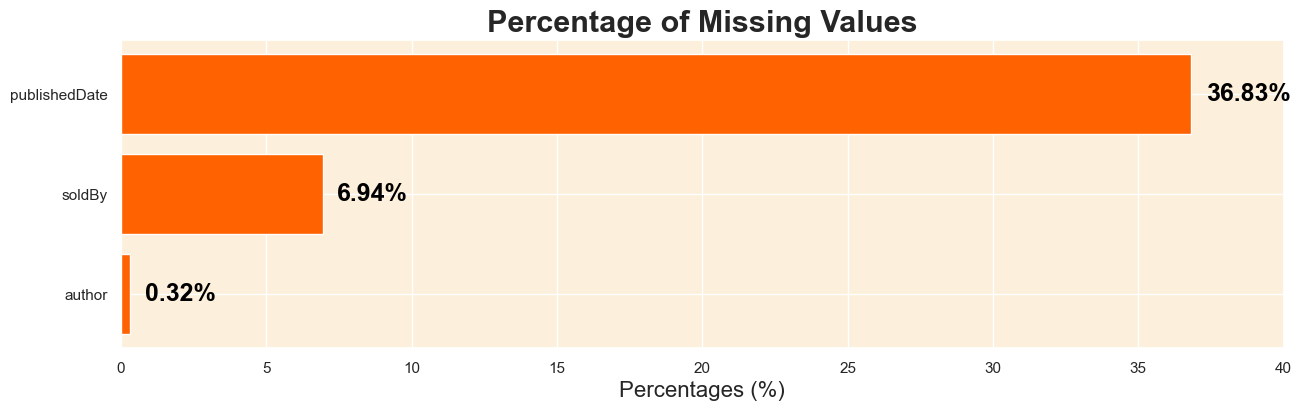

In [19]:
# Calculating the percentage of missing values for each column
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

# Prepare values
missing_percentage.sort_values(ascending=True, inplace=True)

# Plot the barh chart
fig, ax = plt.subplots(figsize=(15, 4))
ax.barh(missing_percentage.index, missing_percentage, color='#ff6200')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=18, color='black')

# Set x-axis limit
ax.set_xlim([0, 40])

# Add title and xlabel
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=22)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()


In [20]:
# Extracting rows with missing values in 'author' or 'soldBy' columns
df[df['author'].isnull() | df['soldBy'].isnull()].head()

,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,category_id,isBestSeller,isEditorsPick,isGoodReadsChoice,publishedDate,category_name
32,B09RX42621,It Starts with Us: the highly anticipated sequ...,Colleen Hoover,NaN,https://m.media-amazon.com/images/I/81G91BUSHs...,https://www.amazon.com/dp/B09RX42621,4.5,0,0.0,False,6,False,True,False,2022-10-18,Parenting & Relationships
33,B017RNBS3A,It Ends With Us: The emotional #1 Sunday Times...,Colleen Hoover,NaN,https://m.media-amazon.com/images/I/817vqET828...,https://www.amazon.com/dp/B017RNBS3A,4.7,0,0.0,False,6,False,False,True,2016-08-02,Parenting & Relationships
99,B00BAJ2MYM,How to Talk to Anyone: 92 Little Tricks for Bi...,Leil Lowndes,NaN,https://m.media-amazon.com/images/I/716i2nRD6T...,https://www.amazon.com/dp/B00BAJ2MYM,4.5,0,0.0,False,6,False,False,False,2013-03-07,Parenting & Relationships
100,B09FQDH5HZ,Seven Husbands of Evelyn Hugo: The Sunday Time...,Taylor Jenkins Reid,NaN,https://m.media-amazon.com/images/I/71QeZB033Y...,https://www.amazon.com/dp/B09FQDH5HZ,4.6,0,0.0,False,6,False,True,False,2021-10-14,Parenting & Relationships
157,B096LZDY32,Stolen Focus: Why You Can't Pay Attention,Johann Hari,NaN,https://m.media-amazon.com/images/I/712SQSzvDh...,https://www.amazon.com/dp/B096LZDY32,4.5,0,0.0,False,6,False,True,False,2022-01-06,Parenting & Relationships


In [21]:
df[df['author'].isnull() | df['soldBy'].isnull()].tail()

,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,category_id,isBestSeller,isEditorsPick,isGoodReadsChoice,publishedDate,category_name
133088,1338746758,Snow Day: A Graphic Novel (Mr. Wolf's Class #5),Aron Nels Steinke,NaN,https://m.media-amazon.com/images/I/71aqgUvqiF...,https://www.amazon.com/dp/1338746758,4.7,0,8.49,False,25,False,False,False,2022-04-05,Children's eBooks
133089,1442428805,A Solitary Blue (3) (The Tillerman Cycle),Cynthia Voigt,NaN,https://m.media-amazon.com/images/I/61PpRfH0H2...,https://www.amazon.com/dp/1442428805,4.6,0,11.99,False,25,False,False,False,2012-03-06,Children's eBooks
133090,B00HG1NG2U,Baby-sitters' European Vacation (Baby-Sitters ...,NaN,NaN,https://m.media-amazon.com/images/I/81OZRZPj+F...,https://www.amazon.com/dp/B00HG1NG2U,4.7,0,4.99,False,25,False,False,False,2022-08-17,Children's eBooks
133091,1524739030,The Kingdom of Back,Marie Lu,NaN,https://m.media-amazon.com/images/I/A1mzDEOIGg...,https://www.amazon.com/dp/1524739030,4.3,0,11.99,False,25,False,False,False,2021-03-02,Children's eBooks
133092,0142417823,The Batboy,Mike Lupica,NaN,https://m.media-amazon.com/images/I/816zv4T0x+...,https://www.amazon.com/dp/0142417823,4.7,0,7.99,False,25,False,False,False,2011-02-22,Children's eBooks


In [22]:
# Convert the publishedDate column to datetime
df['publishedDate'] = pd.to_datetime(df['publishedDate'], errors='coerce')

# Find the minimum and maximum dates
min_date = df['publishedDate'].min()
max_date = df['publishedDate'].max()

# Display the results
print(f"Minimum publishedDate: {min_date}")
print(f"Maximum publishedDate: {max_date}")

Minimum publishedDate: 1806-01-01 00:00:00
Maximum publishedDate: 2024-01-16 00:00:00


In [23]:
# Find the minimum and maximum price
min_price = df['price'].min()
max_price = df['price'].max()

# Display the results
print(f"Minimum price: {min_price}")
print(f"Maximum price: {max_price}")

Minimum price: 0.0
Maximum price: 682.0


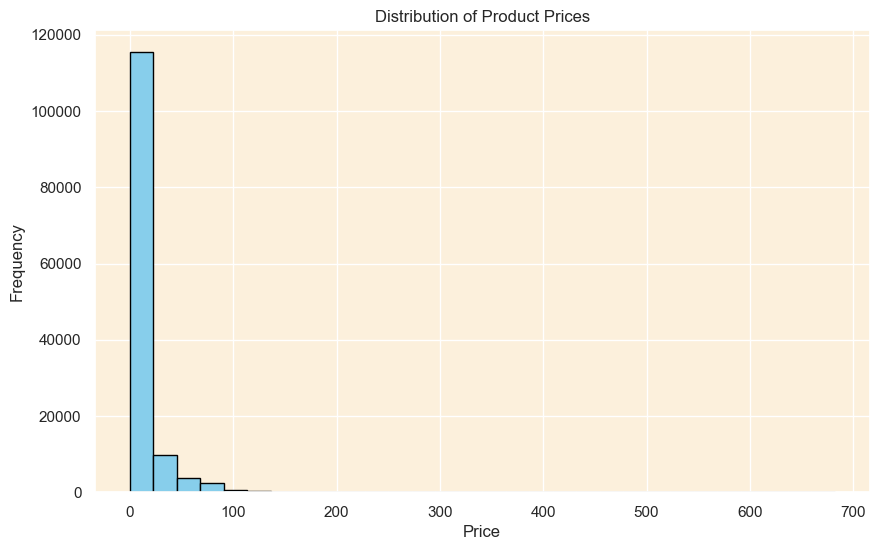

In [24]:
# Customized histogram for 'price'
df['price'].hist(bins=30, color='skyblue', edgecolor='black', figsize=(10, 6))
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [25]:
# Extract the year from the prev_sold_date column
df['publishedYear'] = df['publishedDate'].dt.year

# Calculate the number of years between 2024 and the prev_sold_year
df['years_since_published'] = 2024 - df['publishedYear']

# Display the updated DataFrame
print(df[['publishedDate', 'publishedYear', 'years_since_published']].head())

  publishedDate  publishedYear  years_since_published
0    2015-06-01         2015.0                    9.0
1    2022-02-15         2022.0                    2.0
2    2022-09-13         2022.0                    2.0
3    2020-02-25         2020.0                    4.0
4    2015-05-05         2015.0                    9.0


In [26]:
# Calculate the mean of the years_since_sold column, ignoring NaN values
mean_years_since_published = df['years_since_published'].mean()

# Replace NaN values in the years_since_sold column with the calculated mean
df['years_since_published'].fillna(mean_years_since_published, inplace=True)

# Display the updated DataFrame
print(df[['publishedDate', 'publishedYear', 'years_since_published']].head())

  publishedDate  publishedYear  years_since_published
0    2015-06-01         2015.0                    9.0
1    2022-02-15         2022.0                    2.0
2    2022-09-13         2022.0                    2.0
3    2020-02-25         2020.0                    4.0
4    2015-05-05         2015.0                    9.0


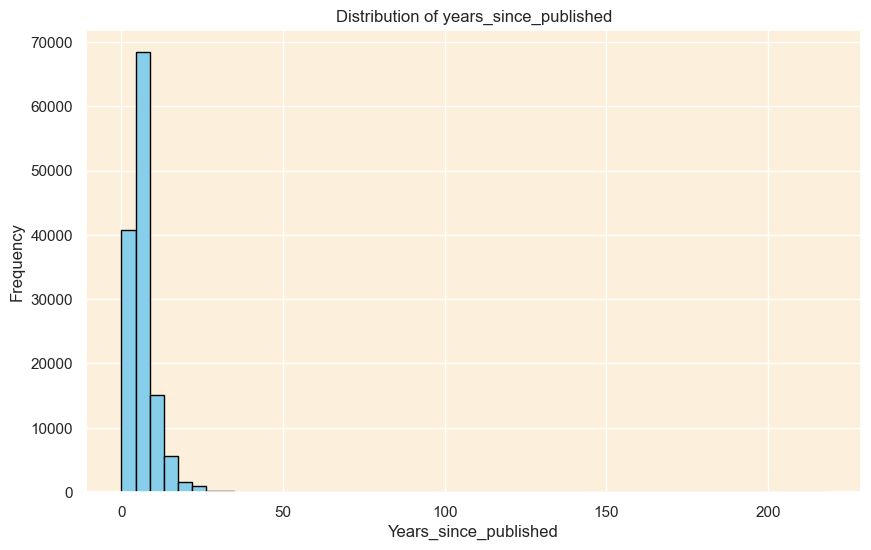

In [27]:
# Customized histogram for 'years_since_published'
df['years_since_published'].hist(bins=50, color='skyblue', edgecolor='black', figsize=(10, 6))
plt.title('Distribution of years_since_published')
plt.xlabel('Years_since_published')
plt.ylabel('Frequency')
plt.show()

In [28]:
df[df['publishedDate'].isnull()].head()

,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,category_id,isBestSeller,isEditorsPick,isGoodReadsChoice,publishedDate,category_name,publishedYear,years_since_published
6,B00AEBEQUK,Expecting Better: Why the Conventional Pregnan...,Emily Oster,Penguin Group (USA) LLC,https://m.media-amazon.com/images/I/81NYWaTY6-...,https://www.amazon.com/dp/B00AEBEQUK,4.6,0,14.99,False,6,True,False,False,NaT,Parenting & Relationships,NaN,6.426088
10,B00AN2JPNI,Moms on Call | Basic Baby Care 0-6 Months | Pa...,Laura Hunter LPN,Amazon.com Services LLC,https://m.media-amazon.com/images/I/717AozsjVZ...,https://www.amazon.com/dp/B00AN2JPNI,4.7,0,24.99,False,6,False,False,False,NaT,Parenting & Relationships,NaN,6.426088
11,B0B69SQNJY,A Little Pinprick (Rainey Paxton Series Book 1),Paige Dearth,Amazon.com Services LLC,https://m.media-amazon.com/images/I/71GoPR+P0e...,https://www.amazon.com/dp/B0B69SQNJY,4.6,0,5.99,True,6,True,False,False,NaT,Parenting & Relationships,NaN,6.426088
12,B07FZPTDJ3,"Cribsheet: A Data-Driven Guide to Better, More...",Emily Oster,Penguin Group (USA) LLC,https://m.media-amazon.com/images/I/81ck+JH5Ty...,https://www.amazon.com/dp/B07FZPTDJ3,4.7,0,14.99,False,6,False,False,False,NaT,Parenting & Relationships,NaN,6.426088
17,B0CBL7RV55,It Starts with the Egg: How the Science of Egg...,Rebecca Fett,Amazon.com Services LLC,https://m.media-amazon.com/images/I/51Kr3Tkha1...,https://www.amazon.com/dp/B0CBL7RV55,4.7,0,9.99,False,6,True,False,False,NaT,Parenting & Relationships,NaN,6.426088


In [29]:
# Replace NaN values in the author column with 'unknown'
df['author'].fillna('unknown', inplace=True)

In [30]:
# Replace NaN values in the soldBy column with 'no record'
df['soldBy'].fillna('no record', inplace=True)

In [31]:
df = df.drop(columns = ['publishedDate','publishedYear'])

In [32]:
# Check for NaN values
print("\nNaN values in the DataFrame:")
print(df.isnull().sum())


NaN values in the DataFrame:
asin                     0
title                    0
author                   0
soldBy                   0
imgUrl                   0
productURL               0
stars                    0
reviews                  0
price                    0
isKindleUnlimited        0
category_id              0
isBestSeller             0
isEditorsPick            0
isGoodReadsChoice        0
category_name            0
years_since_published    0
dtype: int64


In [33]:
df.shape

(133102, 16)

In [34]:
# Handling Duplicates

# Finding duplicate rows (keeping all instances)
duplicate_rows = df[df.duplicated(keep=False)]

# Sorting the data by certain columns to see the duplicate rows next to each other
duplicate_rows_sorted = duplicate_rows.sort_values(by=['asin', 'soldBy'])

# Displaying the first 10 records
duplicate_rows_sorted.head(10)


,asin,title,author,soldBy,imgUrl,productURL,stars,reviews,price,isKindleUnlimited,category_id,isBestSeller,isEditorsPick,isGoodReadsChoice,category_name,years_since_published


In [35]:
# Find the maximum and minimum values for each numerical column
numerical_columns = ['stars', 'reviews', 'price', 'category_id','years_since_published']

# Create a dictionary to store the min and max values
min_max_values = {}

for column in numerical_columns:
    min_max_values[column] = {'min': df[column].min(), 'max': df[column].max()}

# Display the results
for column, values in min_max_values.items():
    print(f"{column}: Min = {values['min']}, Max = {values['max']}")

stars: Min = 0.0, Max = 5.0
reviews: Min = 0, Max = 618227
price: Min = 0.0, Max = 682.0
category_id: Min = 1, Max = 31
years_since_published: Min = 0.0, Max = 218.0


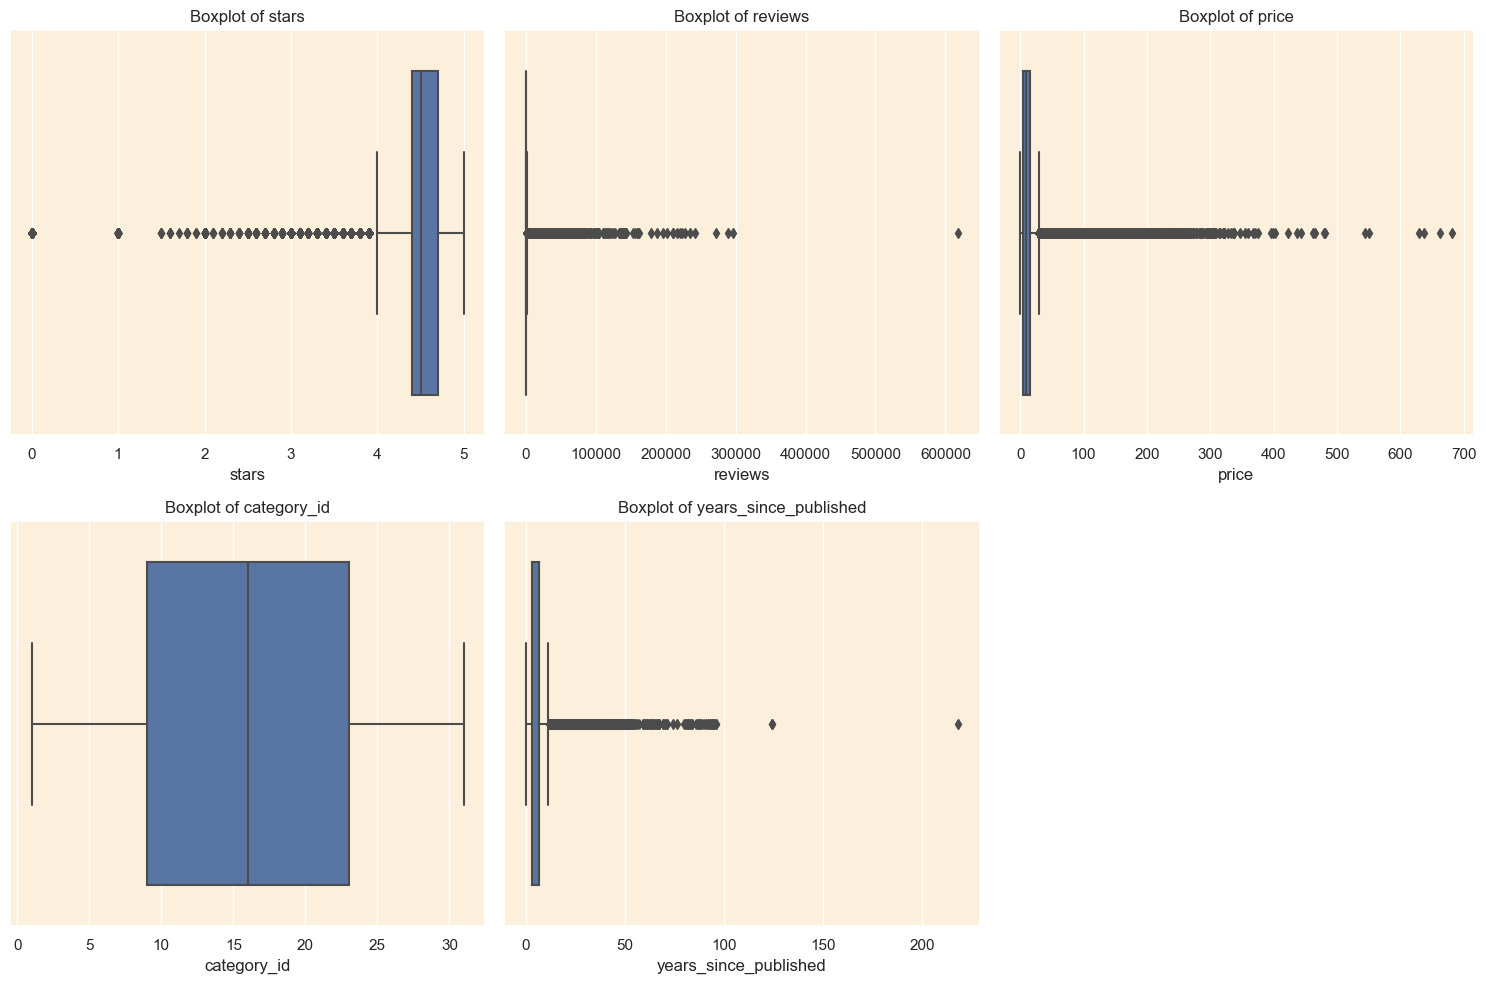

In [36]:
# List of numerical columns
numerical_columns = ['stars', 'reviews', 'price', 'category_id','years_since_published']

# Create a boxplot for each numerical column
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
plt.tight_layout()
plt.show()

In [37]:
# Identify and print abnormal values (outliers) for each numerical column
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Abnormal values in {column}:")
    print(outliers[[column]])
    print("\n")

Abnormal values in stars:
        stars
18        3.9
59        3.9
216       3.7
557       3.9
588       0.0
...       ...
132878    0.0
132925    3.9
132945    2.0
133018    0.0
133076    3.9

[7252 rows x 1 columns]


Abnormal values in reviews:
       reviews
28600    31767
28601    10325
28602   219990
28603    69379
28604   124378
...        ...
98345     1624
98357     1665
98358     1476
98403     1204
98462     4076

[20876 rows x 1 columns]


Abnormal values in price:
        price
104     74.99
119     61.49
249     52.52
265     56.00
275     74.99
...       ...
132630  42.00
132711  59.99
132825  48.13
132855  74.19
132893  31.13

[13491 rows x 1 columns]


Abnormal values in category_id:
Empty DataFrame
Columns: [category_id]
Index: []


Abnormal values in years_since_published:
        years_since_published
5                        19.0
16                       13.0
20                       14.0
21                       18.0
26                       21.0
...             

In [38]:
# Function to remove outliers based on IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers for each numerical column
for column in numerical_columns:
    df = remove_outliers(df, column)

# Display the DataFrame after removing outliers
print(df.describe())

              stars       reviews         price   category_id  \
count  83384.000000  83384.000000  83384.000000  83384.000000   
mean       4.542400    128.777295      9.473114     16.795668   
std        0.222945    232.462492      5.670413      8.431920   
min        4.000000      0.000000      0.000000      1.000000   
25%        4.400000      0.000000      4.990000     10.000000   
50%        4.600000      0.000000      9.950000     18.000000   
75%        4.700000    149.000000     12.990000     24.000000   
max        5.000000   1019.000000     28.520000     31.000000   

       years_since_published  
count           83384.000000  
mean                5.181937  
std                 2.562599  
min                 0.000000  
25%                 3.000000  
50%                 6.426088  
75%                 6.426088  
max                11.000000  


In [39]:
missing = pd.concat([df.isnull().sum(), 100 * df.isnull().mean()], axis=1)
missing.columns=['count','%']
missing.sort_values(by='%')

,count,%
asin,0,0.0
title,0,0.0
author,0,0.0
soldBy,0,0.0
imgUrl,0,0.0
productURL,0,0.0
stars,0,0.0
reviews,0,0.0
price,0,0.0
isKindleUnlimited,0,0.0


In [40]:
df.to_csv('cleaned_file.csv', index=False)

# 4. data Exploratory Data Analysis

In [41]:
df=pd.read_csv('cleaned_file.csv',low_memory=False)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83384 entries, 0 to 83383
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   asin                   83384 non-null  object 
 1   title                  83384 non-null  object 
 2   author                 83384 non-null  object 
 3   soldBy                 83384 non-null  object 
 4   imgUrl                 83384 non-null  object 
 5   productURL             83384 non-null  object 
 6   stars                  83384 non-null  float64
 7   reviews                83384 non-null  int64  
 8   price                  83384 non-null  float64
 9   isKindleUnlimited      83384 non-null  bool   
 10  category_id            83384 non-null  int64  
 11  isBestSeller           83384 non-null  bool   
 12  isEditorsPick          83384 non-null  bool   
 13  isGoodReadsChoice      83384 non-null  bool   
 14  category_name          83384 non-null  object 
 15  ye

In [43]:
df.shape

(83384, 16)

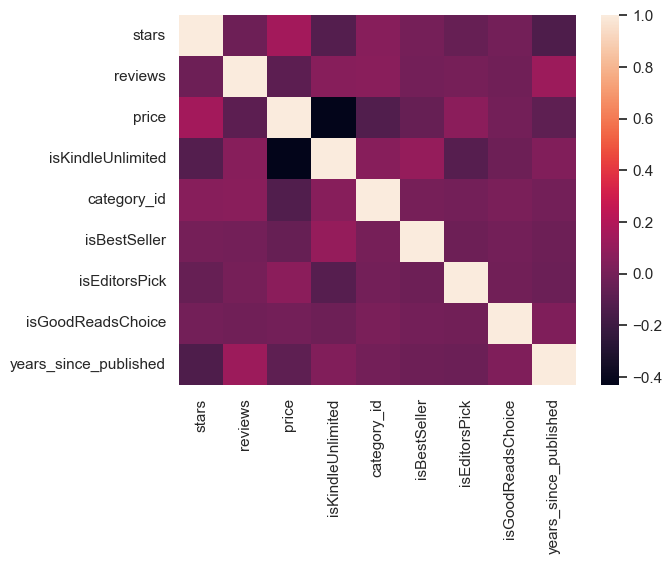

In [44]:
# Make a heatmap of the data 
correlation_matrix = df.corr()
_ = sns.heatmap(correlation_matrix)

In [45]:
df.set_index(['category_id']).groupby(['category_name']).mean()

,stars,reviews,price,isKindleUnlimited,isBestSeller,isEditorsPick,isGoodReadsChoice,years_since_published
category_name,,,,,,,,
Arts & Photo graphy,4.562680,225.598657,11.508280,0.148385,0.014071,0.018868,0.002239,5.437349
Biographies & Memoirs,4.497712,361.329185,11.021939,0.129265,0.026495,0.140104,0.006022,3.922905
Business & Money,4.584477,0.000000,12.080674,0.139765,0.034632,0.012369,0.003711,4.503321
Children's eBooks,4.662827,0.000000,7.425144,0.233238,0.027698,0.057815,0.029237,5.176926
Comics,4.562953,250.420613,11.264067,0.286908,0.000000,0.002786,0.025070,6.462348
Computers & Technology,4.528142,134.134622,13.878772,0.233441,0.014680,0.005729,0.000000,4.373365
"Cookbooks, Food & Wine",4.568589,40.852367,10.219838,0.300426,0.012116,0.132152,0.006955,4.629242
"Crafts, Hobbies & Home",4.579469,10.476770,10.126726,0.290265,0.019912,0.005973,0.002212,4.951420
Education & Teaching,4.554720,160.637981,12.670788,0.230211,0.014524,0.002905,0.000000,5.166771


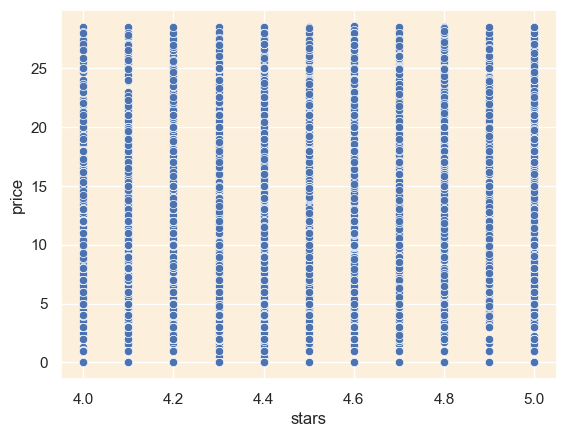

In [46]:
# Plot stars against price
_ = sns.scatterplot(x='stars', y='price', data=df)

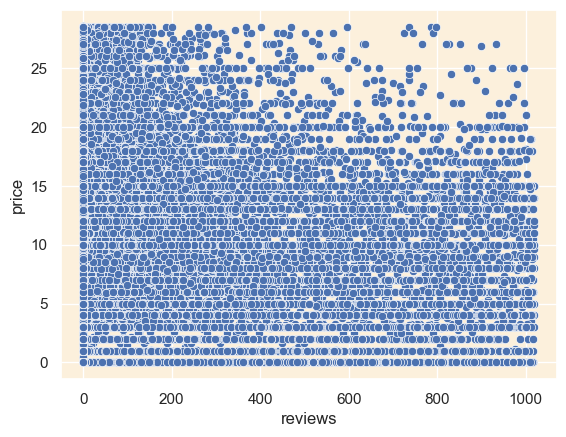

In [47]:
# Plot reviews against price
_ = sns.scatterplot(x='reviews', y='price', data=df)

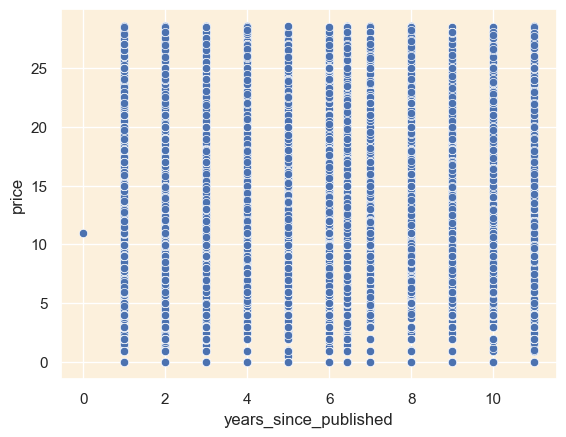

In [48]:
# Plot years_since_published against price
_ = sns.scatterplot(x='years_since_published', y='price', data=df)

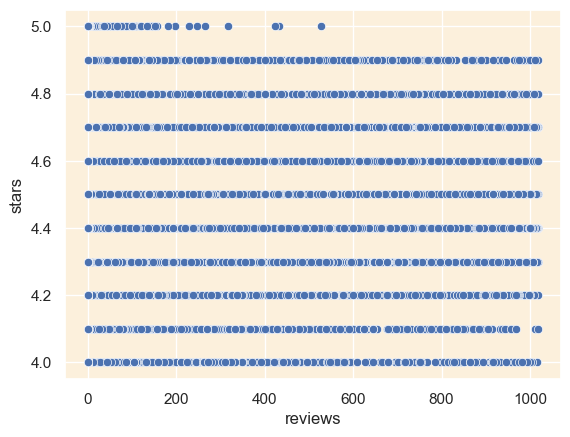

In [49]:
# Plot reviews against stars
_ = sns.scatterplot(x='reviews', y='stars', data=df)

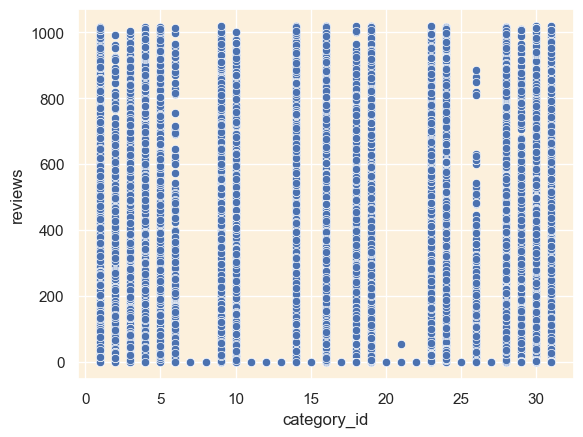

In [52]:
# Plot reviews against stars
_ = sns.scatterplot(x='category_id', y='reviews', data=df)

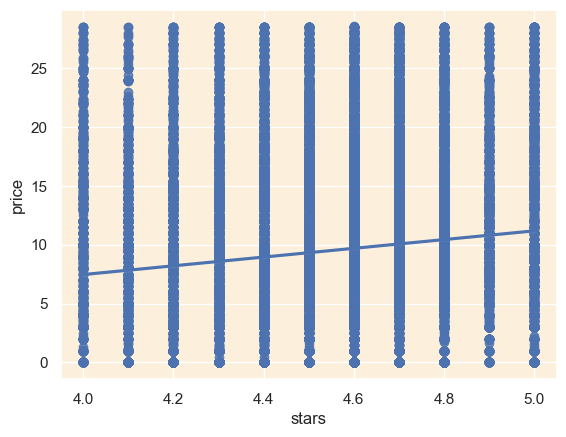

In [50]:
# Call the regplot method on the sns object, with parameters: x = 'stars', y = 'price'
_ = sns.regplot(x='stars', y='price', data=df)

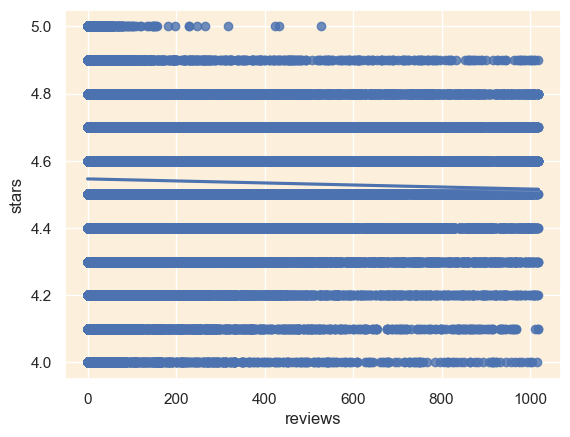

In [51]:
# Call the regplot method on the sns object, with parameters: x = 'reviews', y = 'stars'
_ = sns.regplot(x='reviews', y='stars', data=df)

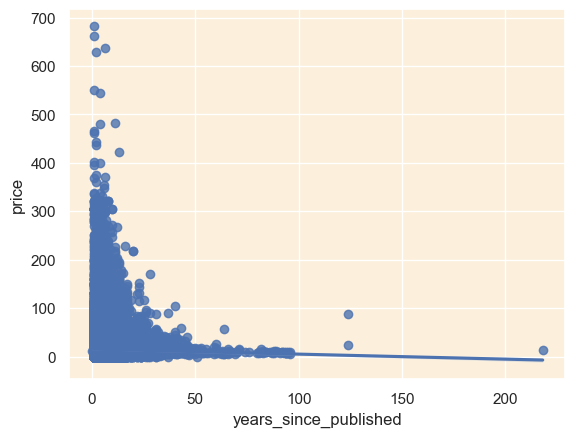

In [49]:
# Call the regplot method on the sns object, with parameters: x = 'years_since_published', y = 'price'
_ = sns.regplot(x='years_since_published', y='price', data=df)